# ViT Fine-tuning: Garment Classifier

Fine-tunes a pretrained Vision Transformer (`google/vit-base-patch16-224`,
HuggingFace `transformers`) on the same 14 garment categories as the CNN
(`03A_cnn_from_scratch_class.ipynb`), to compare a from-scratch CNN against
transfer learning: accuracy, training time, and model size. Inference /
testing on real photos lives in `04B_vit_inference_colab.ipynb`.

**Runtime note:** this notebook works with `RUNTIME="local"`, but a ViT-Base
forward pass is heavy (~86M parameters), on CPU, 20 epochs took multiple
hours in early testing. `RUNTIME="colab"` with a GPU brought the same run
down to about an hour. Colab is strongly recommended for actually training
this notebook; local CPU is realistic only for a quick smoke test.

## 0. Environment setup

In [1]:
#  ENVIRONMENT SETUP
RUNTIME = "colab"     # "colab" or "local"
DEVICE  = "auto"      # "auto", "gpu", or "cpu"

In [2]:
import os
import torch

if RUNTIME == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q transformers

    PROJECT_ROOT = "/content/drive/MyDrive/CNN/wardrove-selector"
elif RUNTIME == "local":
    PROJECT_ROOT = ".."
else:
    raise ValueError(f"Unknown RUNTIME: {RUNTIME!r} (expected 'colab' or 'local')")

import sys
sys.path.append(f"{PROJECT_ROOT}/src")

if DEVICE == "auto":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif DEVICE == "gpu":
    if not torch.cuda.is_available():
        raise RuntimeError("DEVICE='gpu' was requested but no GPU is available in this runtime.")
    device = torch.device('cuda')
elif DEVICE == "cpu":
    device = torch.device('cpu')
else:
    raise ValueError(f"Unknown DEVICE: {DEVICE!r} (expected 'auto', 'gpu', or 'cpu')")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"device       = {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/CNN/wardrove-selector
device       = cuda


## 1. Load the dataset images

Locally, the dataset is already on disk (downloaded once via
`src/download_dataset.py`). In Colab, we download it fresh with `kagglehub`, Colab serves known Kaggle datasets from its own fast local cache, so no
manual copy step is needed (unlike a Drive-mounted folder, which is slow for
thousands of small files, avoid reading images directly from Drive).

In [3]:
if RUNTIME == "colab":
    import kagglehub
    path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
    targets_dir = f"{path}/images"
else:
    from data import targets_dir

print("targets_dir =", targets_dir)
print("exists:", os.path.exists(targets_dir))

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
targets_dir = /kaggle/input/fashion-product-images-small/images
exists: True


## 2. Load the pretrained ViT

In [4]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

checkpoint = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(checkpoint)
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=14,
    ignore_mismatched_sizes=True   # original head had 1000 classes (ImageNet); ours has 14, gets reinitialized
)

[transformers] You passed `num_labels=14` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([14])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([14, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## 3. Freeze the backbone

Only `model.classifier` (the new 14-class head) gets trained. Rationale:
ViT-Base has ~86M parameters vs. ~16k training images, fine-tuning the
whole model would risk severe overfitting. Freezing the pretrained backbone
keeps the only trainable part small (~10k parameters in the head).

In [5]:
for param in model.vit.parameters():
    param.requires_grad = False

print("classifier.weight requires_grad:", model.classifier.weight.requires_grad)

classifier.weight requires_grad: True


## 4. Data pipeline (train/val/test split + DataLoaders)

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from data import ViTGarmentDataset

batch_size = 32

df = pd.read_csv(f"{PROJECT_ROOT}/data/clean_data/clean_df.csv")

# Same split as the CNN (same random_state) -- both models are evaluated on
# the exact same held-out rows, which is what makes the comparison fair.
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["articleType"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["articleType"]
)

train_dataset = ViTGarmentDataset(train_df, targets_dir, processor)
val_dataset = ViTGarmentDataset(val_df, targets_dir, processor)
test_dataset = ViTGarmentDataset(test_df, targets_dir, processor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


## 5. Sanity check: one forward pass

HuggingFace models return an output object, not a raw tensor, the logits
are at `outputs.logits`.

In [7]:
model = model.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))

print("Output:", outputs.logits.shape)   # expected: [32, 14]

Output: torch.Size([32, 14])


## 6. Training loop

In [8]:
import torch.nn.functional as F

def train(model, optimizer, train_loader, val_loader, device, epochs=20):

    train_loss_history = []
    val_loss_history = []
    best_val_loss = float('inf')

    for epoch_index in range(epochs):

        # TRAIN
        model.train()
        train_running_loss = 0.0
        train_num_batches = 0

        for batch_inputs, batch_labels in train_loader:
            batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
            batch_labels = batch_labels.to(device=device, dtype=torch.long)

            logits = model(batch_inputs).logits   # .logits, HF models return an output object, not a bare tensor
            loss = F.cross_entropy(logits, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_running_loss += loss.item()
            train_num_batches += 1

        train_loss_epoch = train_running_loss / train_num_batches
        train_loss_history.append(train_loss_epoch)

        # - VALIDATION
        model.eval()
        val_running_loss = 0.0
        val_num_batches = 0

        with torch.no_grad():
            for batch_inputs, batch_labels in val_loader:
                batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
                batch_labels = batch_labels.to(device=device, dtype=torch.long)

                logits = model(batch_inputs).logits
                loss = F.cross_entropy(logits, batch_labels)

                val_running_loss += loss.item()
                val_num_batches += 1

        val_loss_epoch = val_running_loss / val_num_batches
        val_loss_history.append(val_loss_epoch)

        # Checkpoint only on improvement, val loss never fully plateaus
        # (small val set, no LR scheduler), so the final epoch is not
        # necessarily the best one. See 03A for the same reasoning applied
        # to the CNN.
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            torch.save(model.state_dict(), f"{PROJECT_ROOT}/notebooks/best_model_vit.pt")

        print(
            f"    Epoch {epoch_index+1:02d}  "
            f"    Train loss (avg): {train_loss_epoch:.6f}  "
            f"    Validation loss (avg): {val_loss_epoch:.6f}  "
        )

    return train_loss_history, val_loss_history

## 7. Optimizer

Only `model.classifier.parameters()`, the frozen backbone has
`requires_grad=False`, so passing its parameters to the optimizer would be
harmless but pointless. Same `lr`/`weight_decay` as the CNN, for the same
reasons (Adam default; L2 regularization against overfitting).

In [9]:
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

## 8. Train

~1 hour on a Colab T4 GPU for 20 epochs. On CPU, the same run took multiple
hours in early testing, strongly prefer `RUNTIME="colab"` for this cell.

In [10]:
train_loss_history, val_loss_history = train(
    model, optimizer, train_loader, val_loader, device, epochs=20
)

    Epoch 01      Train loss (avg): 0.388486      Validation loss (avg): 0.321580  
    Epoch 02      Train loss (avg): 0.273059      Validation loss (avg): 0.310102  
    Epoch 03      Train loss (avg): 0.248207      Validation loss (avg): 0.298743  
    Epoch 04      Train loss (avg): 0.232506      Validation loss (avg): 0.289532  
    Epoch 05      Train loss (avg): 0.219137      Validation loss (avg): 0.294421  
    Epoch 06      Train loss (avg): 0.210131      Validation loss (avg): 0.309957  
    Epoch 07      Train loss (avg): 0.203819      Validation loss (avg): 0.305957  
    Epoch 08      Train loss (avg): 0.195907      Validation loss (avg): 0.312783  
    Epoch 09      Train loss (avg): 0.190633      Validation loss (avg): 0.315135  
    Epoch 10      Train loss (avg): 0.187372      Validation loss (avg): 0.301192  
    Epoch 11      Train loss (avg): 0.180619      Validation loss (avg): 0.300496  
    Epoch 12      Train loss (avg): 0.174684      Validation loss (avg): 0.3

## 9. Loss curves

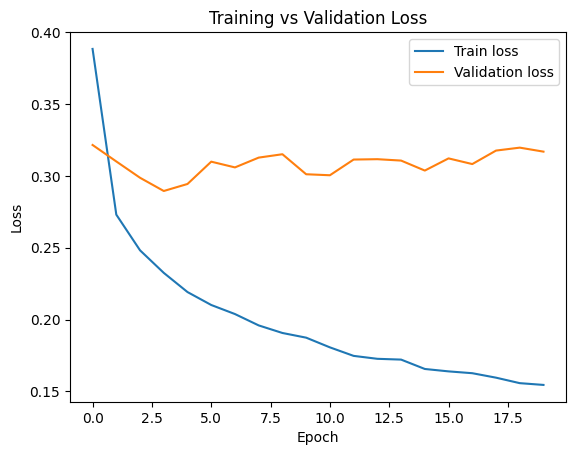

In [11]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Train loss')
plt.plot(val_loss_history, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 10. Evaluation (test set)

Loads the best checkpoint (not necessarily the last epoch) before
evaluating see the checkpointing note in Section 6. `test_loader` is
used here for the first and only time.

In [12]:
model.load_state_dict(torch.load(
    f"{PROJECT_ROOT}/notebooks/best_model_vit.pt",
    map_location=device
))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
        batch_labels = batch_labels.to(device=device, dtype=torch.long)

        logits = model(batch_inputs).logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

### 10.1 Classification report

Macro-F1 (not accuracy) is the primary metric here, given the ~55:1 class
imbalance -- accuracy is dominated by the largest classes and hides poor
performance on the smallest ones. Same reasoning as the CNN evaluation.

In [13]:
from sklearn.metrics import classification_report
from data import categories

print(classification_report(all_labels, all_preds, target_names=categories))

              precision    recall  f1-score   support

     Tshirts       0.94      0.95      0.94       707
      Shirts       0.98      0.98      0.98       322
        Tops       0.75      0.80      0.77       176
       Jeans       0.95      0.97      0.96        61
 Sweatshirts       0.92      0.43      0.59        28
    Sweaters       0.64      0.82      0.72        28
     Jackets       0.83      0.73      0.78        26
     Dresses       0.91      0.91      0.91        46
      Skirts       1.00      0.69      0.82        13
      Shorts       0.96      0.91      0.93        55
 Track Pants       0.86      0.97      0.91        31
Casual Shoes       0.89      0.86      0.87       284
Sports Shoes       0.86      0.88      0.87       203
Formal Shoes       0.81      0.88      0.84        64

    accuracy                           0.90      2044
   macro avg       0.88      0.84      0.85      2044
weighted avg       0.91      0.90      0.90      2044



### 10.2 Confusion matrix

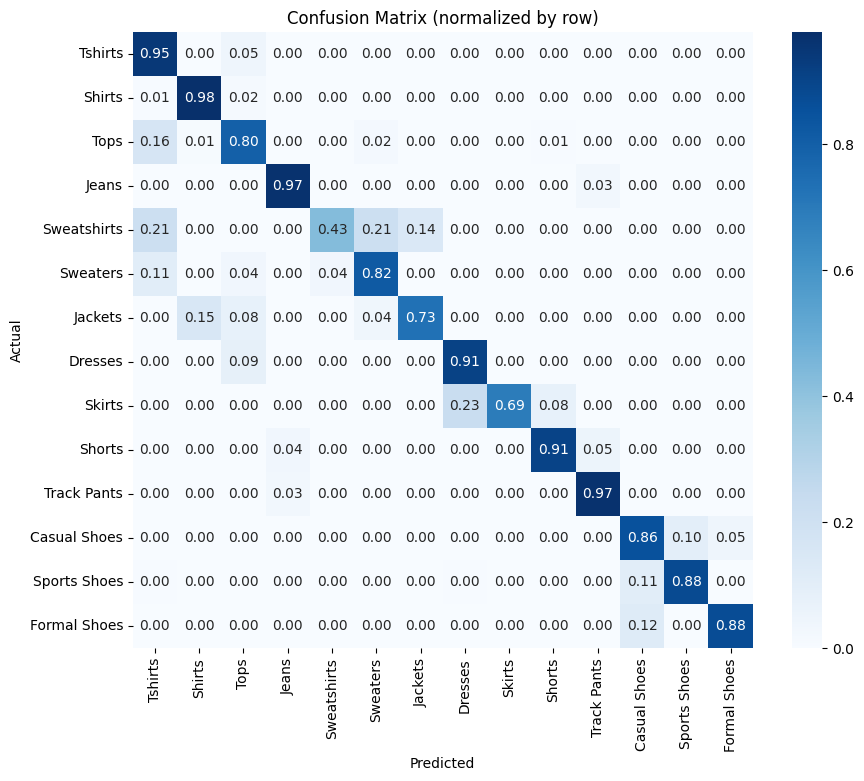

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (normalized by row)')
plt.show()

## 11. Model size

Total parameter count (backbone + head), for the CNN-vs-ViT comparison.

In [15]:
sum(p.numel() for p in model.parameters())

85809422